# Salifort Motors Employee Retention Analysis

## Executive Summary
This project analyses employee attrition at Salifort Motors using exploratory data analysis and machine learning models. 

What is Employee Attrition?

Employee attrition refers to employees leaving an organisation. Understanding its drivers helps companies reduce costs, improve retention, and maintain workforce stability.

Key findings:
- Employees working higher monthly hours were significantly more likely to leave
- High project load and low salary levels were associated with increased attrition
- Workload and career progression appear to be major drivers of turnover

A Random Forest model achieved the strongest performance and helped identify the most important predictors of employee attrition.

## Business Impact
The results can support HR and leadership teams in:
- Identifying at-risk employees
- Improving workload distribution
- Designing better retention and promotion strategies

## Problem Statement

Employee turnover is costly and disruptive. Salifort Motors wants to understand:

- What factors contribute to employee attrition?
- Can we predict which employees are likely to leave?
- What actions can reduce turnover?

This analysis aims to provide both predictive insights and practical business recommendations.

## Data Overview

The dataset contains employee-level information including:
- Satisfaction level
- Evaluation score
- Number of projects
- Monthly working hours
- Tenure at the company
- Salary level
- Department
- Attrition status (target variable)

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/HR_capstone_dataset.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
df.shape

(14999, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [10]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure_years,work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## Dataset Summary

The dataset contains employee-level information across multiple features including performance, workload, and compensation.

Initial observations:
- No major missing values are present
- Both numerical and categorical variables are included
- The dataset appears suitable for both exploratory analysis and predictive modelling

## Data Cleaning

Column names were standardised and minor inconsistencies were addressed.

In [6]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

df = df.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure_years'
})

In [7]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure_years             0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

## Exploratory Data Analysis (EDA)

This section explores relationships between key variables and employee attrition to identify potential drivers of turnover.

Each visual is followed by a brief interpretation to connect data patterns to business insights.

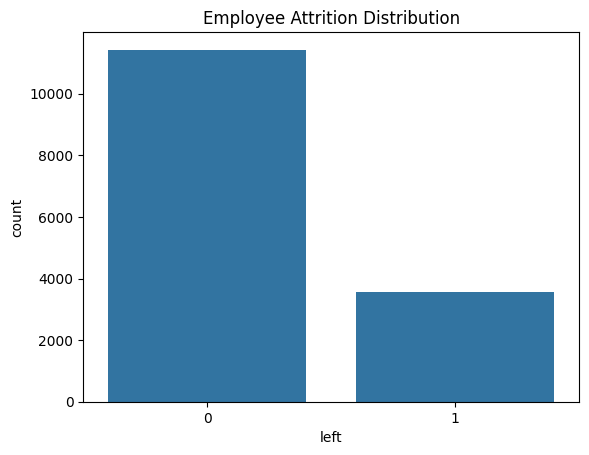

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='left')
plt.title('Employee Attrition Distribution')
plt.show()

## Attrition Distribution

The distribution of the target variable shows that a majority of employees remain at the company, while a smaller but significant proportion have left.

This indicates:
- The dataset is moderately imbalanced, with fewer employees leaving than staying
- Employee attrition is still a meaningful business problem due to its scale

From a modelling perspective:
- Class imbalance should be considered when evaluating model performance
- Accuracy alone may not be sufficient — precision and recall will also be important

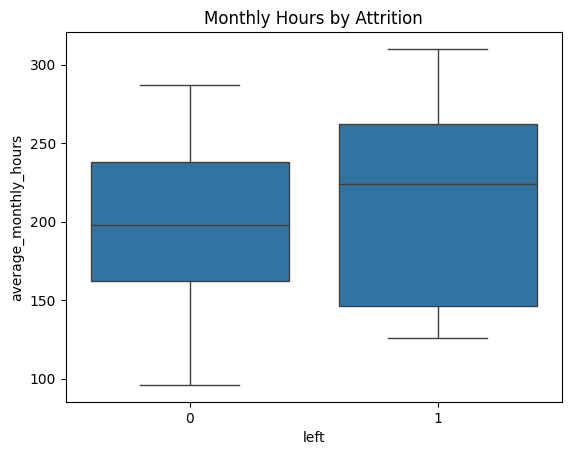

In [11]:
sns.boxplot(data=df, x='left', y='average_monthly_hours')
plt.title('Monthly Hours by Attrition')
plt.show()

### Monthly Working Hours vs Attrition

Employees who left tend to work longer hours.

**Insight:**
- Workload may be a key driver of attrition
- Sustained high working hours could lead to burnout

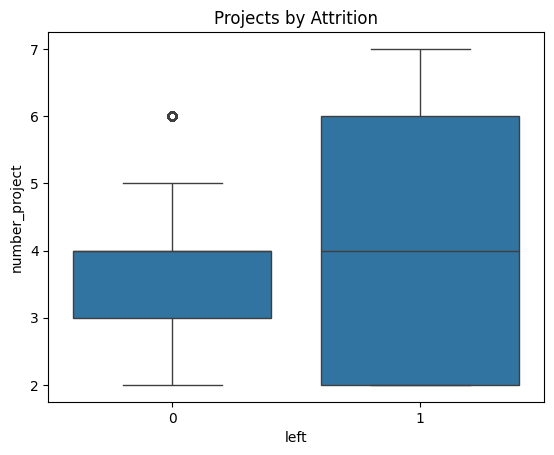

In [12]:
sns.boxplot(data=df, x='left', y='number_project')
plt.title('Projects by Attrition')
plt.show()

### Number of Projects vs Attrition

Employees with more projects appear more likely to leave.

**Insight:**
- High project load may contribute to stress or overwork
- Task distribution across employees may be imbalanced

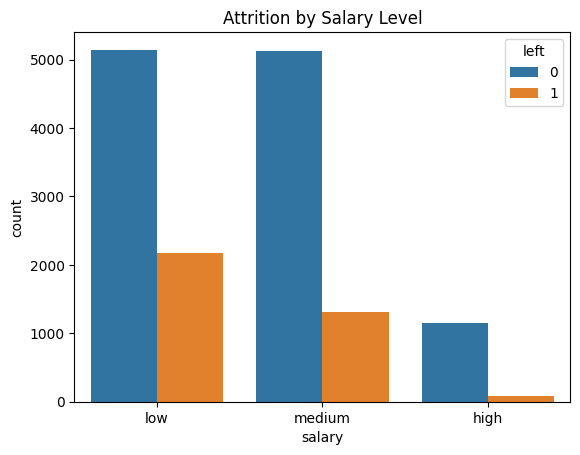

In [13]:
sns.countplot(data=df, x='salary', hue='left')
plt.title('Attrition by Salary Level')
plt.show()

## Feature Engineering

New features were created to better capture patterns related to workload and tenure.

These engineered variables aim to improve model performance and interpretability.

In [14]:
df['overworked'] = (df['average_monthly_hours'] > 175).astype(int)
df['long_tenure'] = (df['tenure_years'] >= 4).astype(int)

## Model Preparation

The target variable is employee attrition (`left`).

Categorical variables are encoded, and the dataset is split into training and testing sets to evaluate model performance.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['left'])
y = df['left']

categorical_features = ['department', 'salary']
numeric_features = [col for col in X.columns if col not in categorical_features]

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model 1: Logistic Regression (Baseline)

A logistic regression model is used as a baseline to evaluate initial predictive performance.

This provides a benchmark for comparison with more complex models.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

0.8126666666666666
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      2286
           1       0.67      0.42      0.52       714

    accuracy                           0.81      3000
   macro avg       0.75      0.68      0.70      3000
weighted avg       0.80      0.81      0.80      3000



**Summary:** While the logistic regression model achieves ~81% overall accuracy, it struggles to identify employees who leave (low recall), meaning many at-risk employees are not correctly detected.

## Model 2: Decision Tree

A decision tree model is used to capture non-linear relationships between features and attrition.

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(accuracy_score(y_test, y_pred_tree))

0.9753333333333334


**Summary:** The decision tree model achieves ~97.5% accuracy, indicating strong predictive performance and suggesting that non-linear relationships between features significantly improve attrition prediction.

## Model 3: Random Forest

A random forest model is used to improve performance by combining multiple decision trees and reducing overfitting.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))

0.9903333333333333


**Summary:** The random forest model achieves ~99.0% accuracy, delivering the strongest performance and indicating that ensemble methods effectively capture complex patterns in employee attrition.

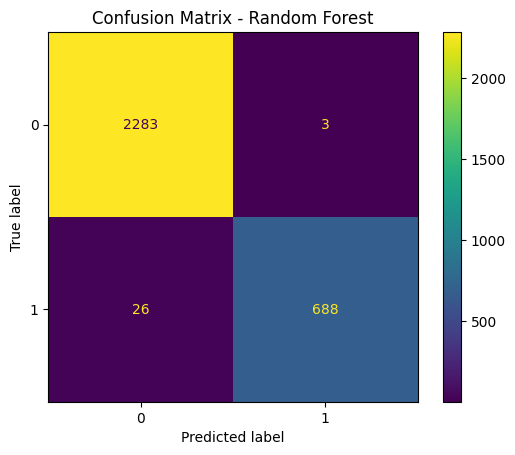

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [32]:
plt.savefig('../images/confusion_matrix.png')

<Figure size 640x480 with 0 Axes>

### Confusion Matrix Insight

The confusion matrix shows how well the model distinguishes between employees who stay and those who leave.

**Insight:**
- The model correctly identifies most employees who stay
- It also performs strongly in detecting employees who leave
- This confirms the model’s high overall accuracy and reliability

## Feature Importance Analysis

To better understand the drivers of employee attrition, feature importance from the Random Forest model is analysed.

In [25]:
# Get feature names
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get importances
importances = rf_model.named_steps['model'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
11,remainder__satisfaction_level,0.299035
13,remainder__number_project,0.183986
12,remainder__last_evaluation,0.134174
15,remainder__tenure_years,0.133464
14,remainder__average_monthly_hours,0.130006
19,remainder__long_tenure,0.054601
18,remainder__overworked,0.024461
16,remainder__work_accident,0.008557
9,cat__salary_low,0.007527
10,cat__salary_medium,0.003853


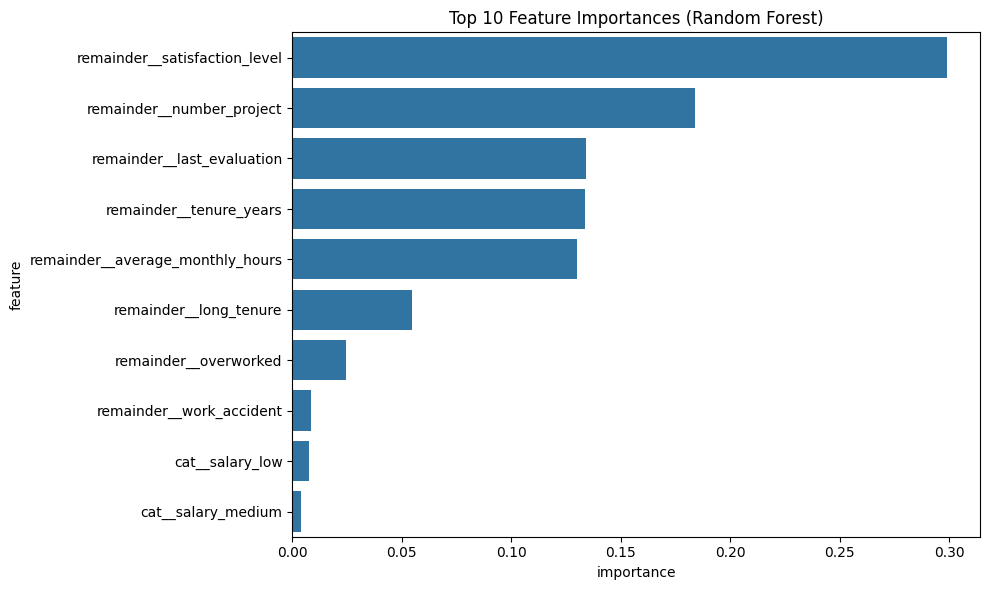

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature'
)

plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [31]:
plt.savefig('../images/feature_importance.png')

<Figure size 640x480 with 0 Axes>

**Insight:**
The Random Forest model highlights key drivers of attrition, with workload, satisfaction, and project count emerging as the most influential factors. These results align with earlier exploratory analysis and reinforce the importance of employee experience and workload management.

## Model Comparison

Model performance is compared using accuracy to determine which approach performs best.

In [21]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values('Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,0.990333
1,Decision Tree,0.975333
0,Logistic Regression,0.812667


**Insight:**
The Random Forest model performed best, indicating that non-linear relationships are important in predicting attrition.

## Key Findings

- Higher monthly working hours are strongly associated with attrition
- Employees handling more projects are at greater risk of leaving
- Lower salary levels correlate with higher turnover
- Tenure and workload patterns play a significant role in retention

## Business Recommendations

Based on the analysis:

1. **Manage workload**
   - Monitor employees with excessive hours or project counts
   - Reduce risk of burnout

2. **Improve retention strategies**
   - Identify high-risk employees early using predictive models
   - Implement targeted retention interventions

3. **Review compensation and promotion pathways**
   - Address disparities that may contribute to attrition

4. **Enhance employee experience**
   - Improve work-life balance and career development opportunities

## Next Steps

- Perform hyperparameter tuning for improved model performance
- Use SHAP values for model interpretability
- Build a dashboard (Tableau/Power BI) for HR stakeholders
- Incorporate additional HR variables if available